In [2]:
import torch
from torch import nn
import numpy as np
import json
from nnunetv2.training.dataloading.data_loader_3d import nnUNetDataLoader3D
from nnunetv2.training.dataloading.nnunet_dataset import nnUNetDataset
from nnunetv2.training.data_augmentation.compute_initial_patch_size import get_patch_size
from nnunetv2.utilities.plans_handling.plans_handler import PlansManager, ConfigurationManager
from batchgenerators.utilities.file_and_folder_operations import join, load_json, maybe_mkdir_p
from nnunetv2.training.data_augmentation.custom_transforms.limited_length_multithreaded_augmenter import \
    LimitedLenWrapper
from sklearn.model_selection import train_test_split
from nnunetv2.utilities.default_n_proc_DA import get_allowed_n_proc_DA

# 데이터 불러오기

preprocessed_dataset_folder = '/home/yoonji/nnUNet/nnUnet_preprocessed/Dataset601_organs_TotalSegmentator/nnUNetPlans_3d_fullres'
splits_file = '/home/yoonji/nnUNet/nnUnet_preprocessed/Dataset601_organs_TotalSegmentator/splits_final.json'
splits = load_json(splits_file)
fold = 0
all_keys = splits[fold]['train']
tr_keys, val_keys = train_test_split(all_keys, test_size=0.15, random_state=42)

dataset_tr = nnUNetDataset(preprocessed_dataset_folder, tr_keys,
                           folder_with_segs_from_previous_stage=None,
                           num_images_properties_loading_threshold=0)
dataset_val = nnUNetDataset(preprocessed_dataset_folder, val_keys,
                            folder_with_segs_from_previous_stage=None,
                            num_images_properties_loading_threshold=0)

### Your nnUNet dataset json
dataset_json =load_json('/home/yoonji/nnUNet/nnUnet_preprocessed/Dataset601_organs_TotalSegmentator/dataset.json')
### Your nnUNet plans json
plans = load_json('/home/yoonji/nnUNet/nnUnet_preprocessed/Dataset601_organs_TotalSegmentator/nnUNetPlans.json')
plans_manager = PlansManager(plans)
### Your configurations

batch_size = 4
configuration_manager = plans_manager.get_configuration('3d_fullres')
label_manager = plans_manager.get_label_manager(dataset_json)
patch_size = configuration_manager.patch_size
dim = len(patch_size)
rotation_for_DA = {
                    'x': (-30. / 360 * 2. * np.pi, 30. / 360 * 2. * np.pi),
                    'y': (-30. / 360 * 2. * np.pi, 30. / 360 * 2. * np.pi),
                    'z': (-30. / 360 * 2. * np.pi, 30. / 360 * 2. * np.pi),
                }
initial_patch_size = get_patch_size(patch_size[-dim:],
                                    *rotation_for_DA.values(),
                                    (0.85, 1.25))
configuration_manager = plans_manager.get_configuration('3d_fullres')
label_manager = plans_manager.get_label_manager(dataset_json)

dl_tr = nnUNetDataLoader3D(dataset_tr, batch_size,
                           initial_patch_size,
                           configuration_manager.patch_size,
                           label_manager,
                           oversample_foreground_percent=0.33,
                           sampling_probabilities=None, pad_sides=None)

iters_train = len(dataset_tr) // batch_size
allowed_num_processes = get_allowed_n_proc_DA()
mt_gen_train = LimitedLenWrapper(iters_train, data_loader=dl_tr, transform=None,
                                 num_processes=allowed_num_processes, num_cached=6, seeds=None,
                                 pin_memory= True, wait_time=0.02)
                                 
inp = next(mt_gen_train)
inp = inp['data']
device = torch.device("cuda:0")


using pin_memory on device 0


In [3]:
train_data = iter(mt_gen_train)

In [4]:
a = next(train_data)

In [5]:
print(a['data'].shape)
print(a['seg'].shape)

(4, 1, 205, 205, 205)
(4, 1, 205, 205, 205)


In [28]:
np.unique(a['seg'])

array([-1,  0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15,
       16, 17], dtype=int16)

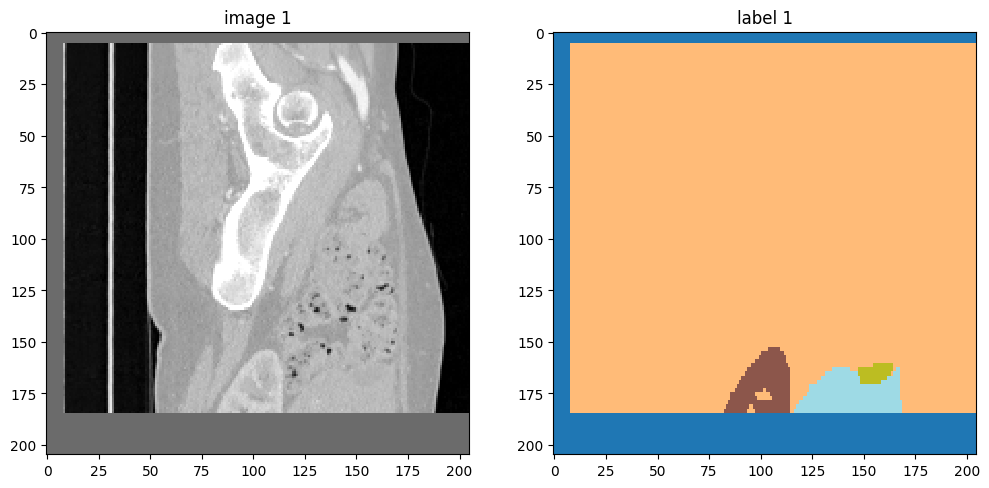

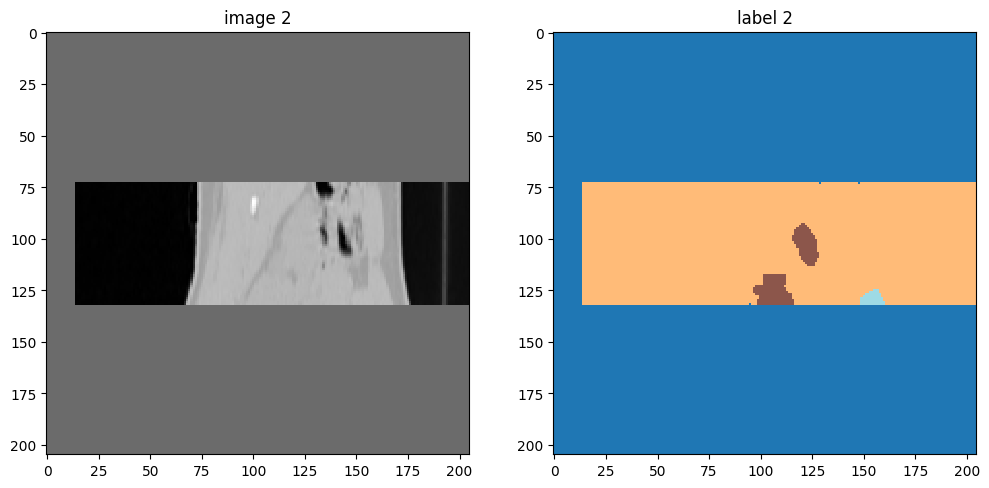

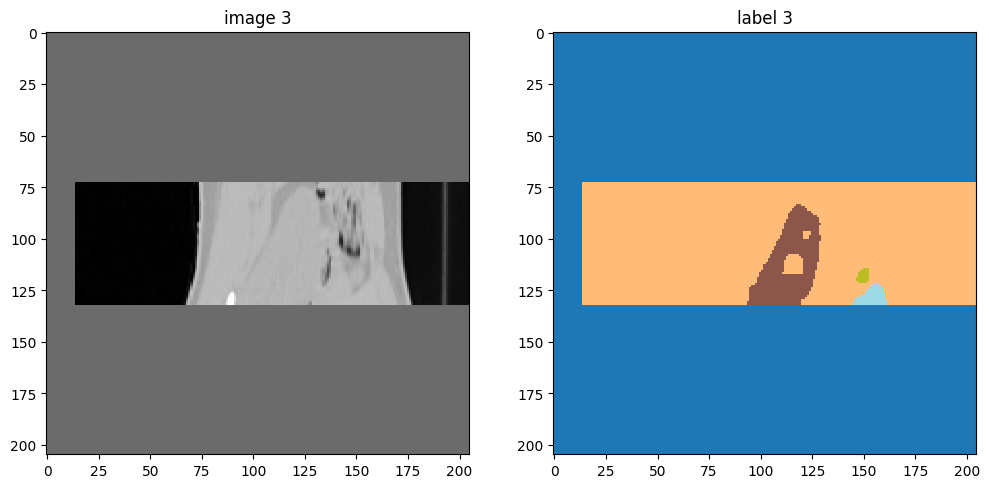

In [7]:
from matplotlib import pyplot as plt
from PIL import Image

def make_2D_inference_samples(data, seg, batch_size, slice_index=None):
    """
    data: 입력 데이터 shape: (4, 1, 205, 205, 205)
    seg : 입력 라벨 shape: (4, 1, 205, 205, 205)
    batch_size: 배치사이즈 4
    slice_index: sampling 할 slice의 인덱스

    배치마다 중앙 depth의 이미지 한장씩 불러와서 시각화
    """

    batch_list = [] # [images from batch 1, ... , images from batch 4]
    for idx in range(batch_size):
        batch_idx_data = data[idx,0], seg[idx,0] # (205, 205, 205) 

        # print("shape of batch_idx data: {}".format(batch_idx_data.shape))

        if slice_index is None:
            total_dpth_slices = batch_idx_data[0].shape[2]
            slices = [total_dpth_slices//2 -10,total_dpth_slices//2 -5, total_dpth_slices//2, total_dpth_slices//2+5, total_dpth_slices//2+10]
            for i in slices:
                img = batch_idx_data[0][:,:,i]
                label = batch_idx_data[1][:,:,i]
                batch_list.append({'image':img, 'label':label})
    
    return batch_list


def visualize_2D_samples(batch_list):
    for idx, sample in enumerate(batch_list[4:7]): # 리스트에서 일단 3개만 샘플
        img = sample['image']
        label = sample['label']
        plt.figure(figsize = (6*2,6))

        # 이미지 시각화
        plt.subplot(1,2,1)
        plt.imshow(img, cmap='gray', interpolation = 'nearest')
        plt.title(f"image {idx+1}")

        # 레이블 시각화
        plt.subplot(1,2,2)
        plt.imshow(label, cmap='tab20', interpolation = 'nearest')
        plt.title(f"label {idx+1}")


        plt.show()

sample_list = make_2D_inference_samples(a['data'], a['seg'], batch_size)
visualize_2D_samples(sample_list)


1.8698317
-1.3587663


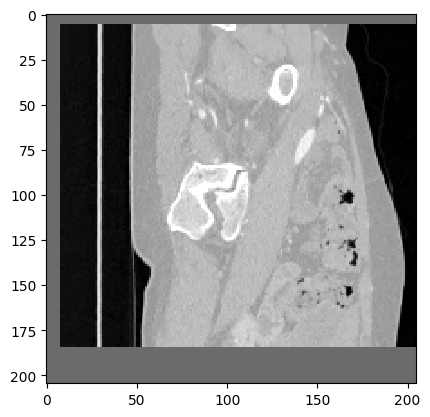

In [30]:
img = a['data'][0].squeeze(0)[:,:,100]
print(img.max())
print(img.min())

plt.imshow(img, cmap='gray', interpolation = 'nearest')

In [33]:
# intensity 조정하는 코드
def normalize_intensity(img):
    img_min = img.min()
    img_max = img.max()
    return (img - img_min) / (img_max - img_min)


def normalize_to_255(img):
    img_normalized = normalize_intensity(img)
    return(img_normalized*255).astype(np.int8)

img_normalized = normalize_intensity(img)
img_255 = normalize_to_255(img)

0.0
1.0


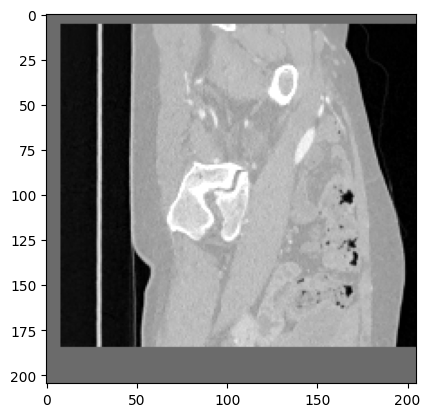

In [39]:
print(img_normalized.min())
print(img_normalized.max())
# plt.imshow(img_normalized, cmap='gray')

In [ ]:
# 선형 조정
def linear_change_intensity(img, scale, shift):
    changed_img = img*scale+shift
    return changed_img

# 비선형 조정Apply gamma correction
def gamma_correction(img, gamma):
    # Normalize to [0, 1] first
    img_normalized = normalize_intensity(img)
    # Apply gamma correction
    img_gamma_corrected = np.power(img_normalized, gamma)
    return img_gamma_corrected

# Example usage
brighter_img = linear_change_intensity(img, scale=1.2, shift=0.2)
# 어둡게 만들기 (scale=0.8, shift=-0.2)
darker_img = linear_change_intensity(img, scale=0.8, shift=-0.2)
gamma_corrected_img = gamma_correction(img, gamma=2.0)  # Brighten dark regions

# 여기서부터는 모델 불러와서 디버깅 하는 용입니다

In [67]:
import torch
torch.cuda.set_device(3)  # 1번 GPU 사용 (nvidia-smi에서 확인된 GPU ID)

device = torch.device('cuda:3')


import matplotlib.pyplot as plt
import matplotlib
matplotlib.use('Agg')
from sklearn.model_selection import train_test_split
import time
from time import sleep
from datetime import datetime
import numpy as np
from timm.utils import ModelEma
import sys
sys.path.insert(0, '/home/yoonji/AnatoMask/')
from nnunetv2.training.lr_scheduler.LinearWarmupCosine import LinearWarmupCosineAnnealingLR
from STUNet_head import STUNet

from encoder3D import SparseEncoder
from decoder3D import LightDecoder
from AnatoMask import SparK

from torch.cuda.amp import GradScaler, autocast

from nnunetv2.training.dataloading.data_loader_3d import nnUNetDataLoader3D
from nnunetv2.training.dataloading.nnunet_dataset import nnUNetDataset
from nnunetv2.training.data_augmentation.compute_initial_patch_size import get_patch_size
from batchgenerators.utilities.file_and_folder_operations import join, load_json, maybe_mkdir_p
from nnunetv2.utilities.plans_handling.plans_handler import PlansManager, ConfigurationManager
from nnunetv2.training.data_augmentation.custom_transforms.limited_length_multithreaded_augmenter import \
    LimitedLenWrapper
from batchgenerators.transforms.abstract_transforms import AbstractTransform, Compose
from batchgenerators.transforms.color_transforms import BrightnessMultiplicativeTransform, \
    ContrastAugmentationTransform, GammaTransform
from batchgenerators.transforms.noise_transforms import GaussianNoiseTransform, GaussianBlurTransform
from batchgenerators.transforms.resample_transforms import SimulateLowResolutionTransform
from batchgenerators.transforms.spatial_transforms import SpatialTransform, MirrorTransform
from batchgenerators.transforms.utility_transforms import RemoveLabelTransform, RenameTransform, NumpyToTensor
from nnunetv2.training.logging.nnunet_logger import nnUNetLogger
from nnunetv2.training.data_augmentation.custom_transforms.cascade_transforms import MoveSegAsOneHotToData, \
    ApplyRandomBinaryOperatorTransform, RemoveRandomConnectedComponentFromOneHotEncodingTransform
from nnunetv2.training.data_augmentation.custom_transforms.deep_supervision_donwsampling import \
    DownsampleSegForDSTransform2
from nnunetv2.training.data_augmentation.custom_transforms.masking import MaskTransform
from nnunetv2.training.data_augmentation.custom_transforms.region_based_training import \
    ConvertSegmentationToRegionsTransform
from nnunetv2.training.data_augmentation.custom_transforms.transforms_for_dummy_2d import Convert2DTo3DTransform, \
    Convert3DTo2DTransform
from nnunetv2.utilities.default_n_proc_DA import get_allowed_n_proc_DA

from typing import Union, Tuple, List

import math
from functools import partial
from torch.utils.data import DataLoader, TensorDataset
from utils.lr_control import lr_wd_annealing, get_param_groups
from utils import dist
import monai

# Training transforms, data augmentation pipelines
def get_training_transforms(patch_size: Union[np.ndarray, Tuple[int]],
                            rotation_for_DA: dict,
                            deep_supervision_scales: Union[List, Tuple],
                            mirror_axes: Tuple[int, ...],
                            do_dummy_2d_data_aug: bool,
                            order_resampling_data: int = 3,
                            order_resampling_seg: int = 1,
                            border_val_seg: int = -1,
                            use_mask_for_norm: List[bool] = None,
                            is_cascaded: bool = False,
                            foreground_labels: Union[Tuple[int, ...], List[int]] = None,
                            regions: List[Union[List[int], Tuple[int, ...], int]] = None,
                            ignore_label: int = None) -> AbstractTransform:
    tr_transforms = []
    if do_dummy_2d_data_aug:
        ignore_axes = (0,)
        tr_transforms.append(Convert3DTo2DTransform())
        patch_size_spatial = patch_size[1:]
    else:
        patch_size_spatial = patch_size
        ignore_axes = None

    # First augmentation transform, dont change
    tr_transforms.append(SpatialTransform(
        patch_size_spatial, patch_center_dist_from_border=None,
        do_elastic_deform=False, alpha=(0, 0), sigma=(0, 0),
        do_rotation=True, angle_x=rotation_for_DA['x'], angle_y=rotation_for_DA['y'], angle_z=rotation_for_DA['z'],
        p_rot_per_axis=1,  # todo experiment with this
        do_scale=True, scale=(0.7, 1.4),
        border_mode_data="constant", border_cval_data=0, order_data=order_resampling_data,
        border_mode_seg="constant", border_cval_seg=border_val_seg, order_seg=order_resampling_seg,
        random_crop=False,  # random cropping is part of our dataloaders
        p_el_per_sample=0, p_scale_per_sample=0.2, p_rot_per_sample=0.2,
        independent_scale_for_each_axis=False  # todo experiment with this
    ))

    if do_dummy_2d_data_aug:
        tr_transforms.append(Convert2DTo3DTransform())


    # CHANGE HERE!!!!!!

    # tr_transforms.append(GaussianNoiseTransform(p_per_sample=0.1))
    # tr_transforms.append(GaussianBlurTransform((0.5, 1.), different_sigma_per_channel=True, p_per_sample=0.2,
    #                                            p_per_channel=0.5))
    # tr_transforms.append(BrightnessMultiplicativeTransform(multiplier_range=(0.75, 1.25), p_per_sample=0.15))
    # tr_transforms.append(ContrastAugmentationTransform(p_per_sample=0.15))
    # tr_transforms.append(SimulateLowResolutionTransform(zoom_range=(0.5, 1), per_channel=True,
    #                                                     p_per_channel=0.5,
    #                                                     order_downsample=0, order_upsample=3, p_per_sample=0.25,
    #                                                     ignore_axes=ignore_axes))
    # tr_transforms.append(GammaTransform((0.7, 1.5), True, True, retain_stats=True, p_per_sample=0.1))
    # tr_transforms.append(GammaTransform((0.7, 1.5), False, True, retain_stats=True, p_per_sample=0.3))

    if mirror_axes is not None and len(mirror_axes) > 0:
        tr_transforms.append(MirrorTransform(mirror_axes))

    if use_mask_for_norm is not None and any(use_mask_for_norm):
        tr_transforms.append(MaskTransform([i for i in range(len(use_mask_for_norm)) if use_mask_for_norm[i]],
                                           mask_idx_in_seg=0, set_outside_to=0))

    tr_transforms.append(RemoveLabelTransform(-1, 0))

    if is_cascaded:
        assert foreground_labels is not None, 'We need foreground_labels for cascade augmentations'
        tr_transforms.append(MoveSegAsOneHotToData(1, foreground_labels, 'seg', 'data'))
        tr_transforms.append(ApplyRandomBinaryOperatorTransform(
            channel_idx=list(range(-len(foreground_labels), 0)),
            p_per_sample=0.4,
            key="data",
            strel_size=(1, 8),
            p_per_label=1))
        tr_transforms.append(
            RemoveRandomConnectedComponentFromOneHotEncodingTransform(
                channel_idx=list(range(-len(foreground_labels), 0)),
                key="data",
                p_per_sample=0.2,
                fill_with_other_class_p=0,
                dont_do_if_covers_more_than_x_percent=0.15))

    tr_transforms.append(RenameTransform('seg', 'target', True))

    if regions is not None:
        # the ignore label must also be converted
        tr_transforms.append(ConvertSegmentationToRegionsTransform(list(regions) + [ignore_label]
                                                                   if ignore_label is not None else regions,
                                                                   'target', 'target'))

    if deep_supervision_scales is not None:
        tr_transforms.append(DownsampleSegForDSTransform2(deep_supervision_scales, 0, input_key='target',
                                                          output_key='target'))
    tr_transforms.append(NumpyToTensor(['data', 'target'], 'float'))
    tr_transforms = Compose(tr_transforms)
    return tr_transforms

def get_validation_transforms(deep_supervision_scales: Union[List, Tuple],
                              is_cascaded: bool = False,
                              foreground_labels: Union[Tuple[int, ...], List[int]] = None,
                              regions: List[Union[List[int], Tuple[int, ...], int]] = None,
                              ignore_label: int = None) -> AbstractTransform:
    val_transforms = []
    val_transforms.append(RemoveLabelTransform(-1, 0))

    if is_cascaded:
        val_transforms.append(MoveSegAsOneHotToData(1, foreground_labels, 'seg', 'data'))

    val_transforms.append(RenameTransform('seg', 'target', True))

    if regions is not None:
        # the ignore label must also be converted
        val_transforms.append(ConvertSegmentationToRegionsTransform(list(regions) + [ignore_label]
                                                                    if ignore_label is not None else regions,
                                                                    'target', 'target'))

    if deep_supervision_scales is not None:
        val_transforms.append(DownsampleSegForDSTransform2(deep_supervision_scales, 0, input_key='target',
                                                           output_key='target'))

    val_transforms.append(NumpyToTensor(['data', 'target'], 'float'))
    val_transforms = Compose(val_transforms)
    return val_transforms

In [68]:

# 데이터 불러오기
### Your preprocessed dataset folder
preprocessed_dataset_folder = '/home/yoonji/nnUNet/nnUnet_preprocessed/Dataset601_organs_TotalSegmentator/nnUNetPlans_3d_fullres'
### Your nnUNet splits json
splits_file = '/home/yoonji/nnUNet/nnUnet_preprocessed/Dataset601_organs_TotalSegmentator/splits_final.json'
splits = load_json(splits_file)

all_keys = splits[fold]['train']
tr_keys, val_keys = train_test_split(all_keys, test_size=0.15, random_state=42)

dataset_tr = nnUNetDataset(preprocessed_dataset_folder, tr_keys,
                           folder_with_segs_from_previous_stage=None,
                           num_images_properties_loading_threshold=0)
dataset_val = nnUNetDataset(preprocessed_dataset_folder, val_keys,
                            folder_with_segs_from_previous_stage=None,
                            num_images_properties_loading_threshold=0)
### Your nnUNet dataset json
dataset_json =load_json('/home/yoonji/nnUNet/nnUnet_preprocessed/Dataset601_organs_TotalSegmentator/dataset.json')
### Your nnUNet plans json
plans = load_json('/home/yoonji/nnUNet/nnUnet_preprocessed/Dataset601_organs_TotalSegmentator/nnUNetPlans.json')
plans_manager = PlansManager(plans)
### Your configurations
configuration_manager = plans_manager.get_configuration('3d_fullres')
label_manager = plans_manager.get_label_manager(dataset_json)

# patch_size = configuration_manager.patch_size
patch_size = [112,112, 128]
dim = len(patch_size)
rotation_for_DA = {
                    'x': (-30. / 360 * 2. * np.pi, 30. / 360 * 2. * np.pi),
                    'y': (-30. / 360 * 2. * np.pi, 30. / 360 * 2. * np.pi),
                    'z': (-30. / 360 * 2. * np.pi, 30. / 360 * 2. * np.pi),
                }
initial_patch_size = get_patch_size(patch_size[-dim:],
                                    *rotation_for_DA.values(),
                                    (0.85, 1.25))

dl_tr = nnUNetDataLoader3D(dataset_tr, batch_size,
                           initial_patch_size,
                        #    configuration_manager.patch_size,
                        patch_size,
                           label_manager,
                           oversample_foreground_percent=0.33,
                           sampling_probabilities=None, pad_sides=None)

iters_train = len(dataset_tr) // batch_size

deep_supervision_scales = list(list(i) for i in 1 / np.cumprod(np.vstack(
            pool_op_kernel_sizes), axis=0))[:-1]
mirror_axes = (0, 1, 2)

tr_transforms = get_training_transforms(
    patch_size, rotation_for_DA, deep_supervision_scales, mirror_axes, False,
    order_resampling_data=3, order_resampling_seg=1,
    use_mask_for_norm=configuration_manager.use_mask_for_norm,
    is_cascaded=False, foreground_labels=label_manager.foreground_labels,
    regions=label_manager.foreground_regions if label_manager.has_regions else None,
    ignore_label=label_manager.ignore_label)

val_transforms = get_validation_transforms(
    deep_supervision_scales,
    is_cascaded=False,
    foreground_labels=label_manager.foreground_labels,
    regions=label_manager.foreground_regions if
    label_manager.has_regions else None,
    ignore_label=label_manager.ignore_label)

allowed_num_processes = get_allowed_n_proc_DA()

mt_gen_train = LimitedLenWrapper(iters_train, data_loader=dl_tr, transform=tr_transforms,
                                 num_processes=allowed_num_processes, num_cached=6, seeds=None,
                                 pin_memory= True, wait_time=0.02)


inp=next(mt_gen_train)
inp = inp['data']
inp = inp.to(device, non_blocking=True)

using pin_memory on device 3


In [69]:
inp.shape

torch.Size([4, 1, 112, 112, 128])

In [70]:
# masking 이 어떤 식으로 되나 봐야함
# model 불러옴러옴

pool_op_kernel_sizes = [[2, 2, 2], [2, 2, 2], [2, 2, 2], [2, 2, 2], [1,1,1]]
conv_kernel_sizes =  [[3, 3, 3], [3, 3, 3], [3, 3, 3], [3, 3, 3], [3, 3, 3], [3, 3, 3]]

# STUNet_B
head = STUNet(1,1,depth=[1, 1, 1, 1, 1, 1], dims=[32, 64, 128, 256, 512, 512], pool_op_kernel_sizes = pool_op_kernel_sizes, conv_kernel_sizes = conv_kernel_sizes,
               enable_deep_supervision=True).to(device)
model_name = 'STUNet_B'

class LocalDDP(torch.nn.Module):
    def __init__(self, module):
        super(LocalDDP, self).__init__()
        self.module = module

    def forward(self, *args, **kwargs):
        return self.module(*args, **kwargs)
input_size = (112, 112, 128)

enc = SparseEncoder(head, input_size=input_size, sbn=False).to(device)
dec = LightDecoder(enc.downsample_ratio,sbn=False, width = 512, out_channel = 1).to(device)

model_without_ddp = SparK(
    sparse_encoder=enc, dense_decoder=dec, mask_ratio=0.6,
    densify_norm='in'
).to(device)

model_ema = ModelEma(model_without_ddp, decay=0.999, device=device, resume='')


model = LocalDDP(model_without_ddp)
mask1 = model.module.mask(batch_size, device)
inp = inp.to(device, non_blocking=True)
inp1, rec1 = model(inp, active_b1ff=mask1)



[SparK.__init__, densify 1/5]: use nn.Identity() as densify_proj
[SparK.__init__, densify 2/5]: densify_proj(ksz=3, #para=1.77M)
[SparK.__init__, densify 3/5]: densify_proj(ksz=3, #para=0.44M)
[SparK.__init__, densify 4/5]: densify_proj(ksz=3, #para=0.11M)
[SparK.__init__, densify 5/5]: densify_proj(ksz=3, #para=0.03M)
[SparK.__init__] dims of mask_tokens=(512, 256, 128, 64, 32)


ValueError: too many values to unpack (expected 2)

In [71]:
import torch

# GPU 메모리 캐시 초기화
torch.cuda.empty_cache()
print("Unused GPU memory cleared.")


Unused GPU memory cleared.


In [ ]:
# uncertainty map 뽑는 코드


In [ ]:
def mask_uncertainty(self, B: int, device, uncertainty_map:torch.Tensor): # masking based on uncertainty
    """
    Args:
        B: Batch size
        uncertainty_map: (B, fmap_h, fmap_w, fmap_d)

    Returns:
        mask: Boolean mask of shape (B, 1, fmap_h, fmap_w, fmap_d).
    """
    h, w, d = self.fmap_h, self.fmap_w, self.fmap_d # (7, 7, 8)
    # flatten for thresholding
    uncertainty_flat = uncertainty_map.view(B, -1)
    top_k = int(0.4*uncertainty_flat.shape[1]) # 40% 에 해당하는 개수
    # value 와 index 반환
    threshold, _ = torch.kthvalue(uncertainty_flat, uncertainty_flat.shape[1] - top_k, dim=1)
    threshold = threshold.view(B,1,1,1)
    mask = (uncertainty_map >= threshold).to(device)
    mask = mask.unsqueeze(1)
    return mask

* sample_list 는 각 요소마다 image, label을 key로 가지고, 각각 2d numpy array를 value로 가지는 리스트임.
* model inference 및 시각화 할 때 사용

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
from torchvision import transforms
import torch.nn as nn
from torch.utils.data import DataLoader,Dataset
import torch
import torch.optim as optim
from torch.autograd import Variable

In [9]:
def add_noise(img,noise_type="gaussian"):
  
  row,col= 205, 205
  img=img.astype(np.float32)
  
  if noise_type=="gaussian":
    mean=0
    var=10
    sigma=var**.5
    noise=np.random.normal(-5.9,5.9,img.shape)
    noise=noise.reshape(row,col)
    img=img+noise
    return img

  if noise_type=="speckle":
    noise=np.random.randn(row,col)
    noise=noise.reshape(row,col)
    img=img+img*noise
    return img

In [10]:
one_img = sample_list[0]['image']

In [11]:
one_img.shape

(205, 205)

In [12]:
len(sample_list)

20

In [13]:
"""
From here onwards,we split the 60k training datapoints into 3 sets each given one type of each noise.
We shuffle them for better generalization.
"""
noises=["gaussian","speckle"]
noise_ct=0
noise_id=0
traindata=np.zeros((len(sample_list),205,205))



for idx in tqdm(range(len(sample_list))):
  
  if noise_ct<(len(sample_list)/2):
    noise_ct+=1
    traindata[idx]=add_noise(sample_list[idx]['image'],noise_type=noises[noise_id])
    
  else:
    print("\n{} noise addition completed to images".format(noises[noise_id]))
    noise_id+=1
    noise_ct=0


print("\n{} noise addition completed to images".format(noises[noise_id])) 
# noise_ct=0
# noise_id=0
# testdata=np.zeros((10000,28,28))

# for idx in tqdm(range(len(xtest))):
  
#   if noise_ct<(len(xtest)/2):
#     noise_ct+=1
#     x=add_noise(xtest[idx],noise_type=noises[noise_id])
#     testdata[idx]=x
    
#   else:
#     print("\n{} noise addition completed to images".format(noises[noise_id]))
#     noise_id+=1
#     noise_ct=0


# print("\n{} noise addition completed to images".format(noises[noise_id]))

100%|██████████| 20/20 [00:00<00:00, 316.31it/s]


gaussian noise addition completed to images

speckle noise addition completed to images


Text(0.5, 1.0, 'Noised Image')

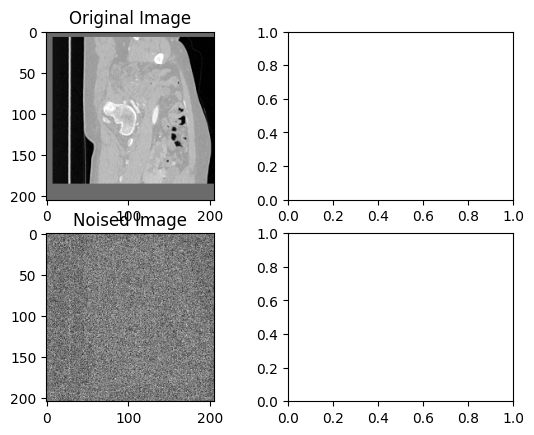

In [14]:
f, axes=plt.subplots(2,2)

#showing images with gaussian noise
axes[0,0].imshow(sample_list[0]['image'],cmap="gray")
axes[0,0].set_title("Original Image")
axes[1,0].imshow(traindata[0],cmap='gray')
axes[1,0].set_title("Noised Image")

# #showing images with speckle noise
# axes[0,1].imshow(xtrain[25000],cmap='gray')
# axes[0,1].set_title("Original Image")
# axes[1,1].imshow(traindata[25000],cmap="gray")
# axes[1,1].set_title("Noised Image")

In [15]:
class noisedDataset(Dataset):
  
  def __init__(self,datasetnoised,datasetclean,labels,transform):
    self.noise=datasetnoised
    self.clean=datasetclean
    self.labels=labels
    self.transform=transform
  
  def __len__(self):
    return len(self.noise)
  
  def __getitem__(self,idx):
    xNoise=self.noise[idx]
    xClean=self.clean[idx]
    y=self.labels[idx]
    
    if self.transform != None:
      xNoise=self.transform(xNoise)
      xClean=self.transform(xClean)
      
    
    return (xNoise,xClean,y)
      

In [16]:
tsfms=transforms.Compose([
    transforms.ToTensor()
])

trainset=noisedDataset(traindata,xtrain,ytrain,tsfms)
testset=noisedDataset(testdata,xtest,ytest,tsfms)

NameError: name 'xtrain' is not defined

In [ ]:

"""
Here , we create the trainloaders and testloaders.
Also, we transform the images using standard lib functions
"""

batch_size=32


trainloader=DataLoader(trainset,batch_size=32,shuffle=True)
testloader=DataLoader(testset,batch_size=1,shuffle=True)

In [ ]:
"""
Here, we define the autoencoder model.
"""

class denoising_model(nn.Module):
  def __init__(self):
    super(denoising_model,self).__init__()
    self.encoder=nn.Sequential(
                  nn.Linear(28*28,256),
                  nn.ReLU(True),
                  nn.Linear(256,128),
                  nn.ReLU(True),
                  nn.Linear(128,64),
                  nn.ReLU(True)
        
                  )
    
    self.decoder=nn.Sequential(
                  nn.Linear(64,128),
                  nn.ReLU(True),
                  nn.Linear(128,256),
                  nn.ReLU(True),
                  nn.Linear(256,28*28),
                  nn.Sigmoid(),
                  )
    
 
  def forward(self,x):
    x=self.encoder(x)
    x=self.decoder(x)
    
    return x
  

In [ ]:
#We check whether cuda is available and choose device accordingly
if torch.cuda.is_available()==True:
  device="cuda:0"
else:
  device ="cpu"

  
model=denoising_model().to(device)
criterion=nn.MSELoss()
optimizer=optim.SGD(model.parameters(),lr=0.01,weight_decay=1e-5)


epochs=120
l=len(trainloader)
losslist=list()
epochloss=0
running_loss=0
for epoch in range(epochs):
  
  print("Entering Epoch: ",epoch)
  for dirty,clean,label in tqdm((trainloader)):
    
    
    dirty=dirty.view(dirty.size(0),-1).type(torch.FloatTensor)
    clean=clean.view(clean.size(0),-1).type(torch.FloatTensor)
    dirty,clean=dirty.to(device),clean.to(device)
    
    
    
    #-----------------Forward Pass----------------------
    output=model(dirty)
    loss=criterion(output,clean)
    #-----------------Backward Pass---------------------
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    
    running_loss+=loss.item()
    epochloss+=loss.item()
  #-----------------Log-------------------------------
  losslist.append(running_loss/l)
  running_loss=0
  print("======> epoch: {}/{}, Loss:{}".format(epoch,epochs,loss.item()))

In [ ]:
plt.plot(range(len(losslist)),losslist)

In [ ]:

"""Here, we try to visualize some of the results.
  We randomly generate 6 numbers in between 1 and 10k , run them through the model,
  and show the results with comparisons
  
 """




f,axes= plt.subplots(6,3,figsize=(20,20))
axes[0,0].set_title("Original Image")
axes[0,1].set_title("Dirty Image")
axes[0,2].set_title("Cleaned Image")

test_imgs=np.random.randint(0,10000,size=6)
for idx in range((6)):
  dirty=testset[test_imgs[idx]][0]
  clean=testset[test_imgs[idx]][1]
  label=testset[test_imgs[idx]][2]
  dirty=dirty.view(dirty.size(0),-1).type(torch.FloatTensor)
  dirty=dirty.to(device)
  output=model(dirty)
  
  output=output.view(1,28,28)
  output=output.permute(1,2,0).squeeze(2)
  output=output.detach().cpu().numpy()
  
  dirty=dirty.view(1,28,28)
  dirty=dirty.permute(1,2,0).squeeze(2)
  dirty=dirty.detach().cpu().numpy()
  
  clean=clean.permute(1,2,0).squeeze(2)
  clean=clean.detach().cpu().numpy()
  
  axes[idx,0].imshow(clean,cmap="gray")
  axes[idx,1].imshow(dirty,cmap="gray")
  axes[idx,2].imshow(output,cmap="gray")

STUNET encoder decoder check

In [ ]:
import torch

class STUNet(nn.Module):
    def __init__(self, input_channels, num_classes, depth=[1, 1, 1, 1, 1, 1], dims=[32, 64, 128, 256, 512, 512],
                 pool_op_kernel_sizes=None, conv_kernel_sizes=None, enable_deep_supervision=True, dropout_ratio=0.5):
        super().__init__()
        self.conv_op = nn.Conv3d
        self.input_channels = input_channels
        self.num_classes = num_classes

        self.final_nonlin = lambda x: x
        self.decoder = Decoder()
        self.decoder.deep_supervision = enable_deep_supervision
        self.upscale_logits = False

        self.dropout_ratio=0.5
        self.pool_op_kernel_sizes = pool_op_kernel_sizes
        self.conv_kernel_sizes = conv_kernel_sizes
        self.conv_pad_sizes = []
        for krnl in self.conv_kernel_sizes:
            self.conv_pad_sizes.append([i // 2 for i in krnl])

        num_pool = len(pool_op_kernel_sizes)

        assert num_pool == len(dims) - 1

        # encoder
        self.conv_blocks_context = nn.ModuleList()
        stage = nn.Sequential(
            BasicResBlock(input_channels, dims[0], self.conv_kernel_sizes[0], self.conv_pad_sizes[0], use_1x1conv=True),
            *[BasicResBlock(dims[0], dims[0], self.conv_kernel_sizes[0], self.conv_pad_sizes[0]) for _ in
              range(depth[0] - 1)])
        self.conv_blocks_context.append(stage)
        for d in range(1, num_pool + 1):
            stage = nn.Sequential(BasicResBlock(dims[d - 1], dims[d], self.conv_kernel_sizes[d], self.conv_pad_sizes[d],
                                                stride=self.pool_op_kernel_sizes[d - 1], use_1x1conv=True),
                                  *[BasicResBlock(dims[d], dims[d], self.conv_kernel_sizes[d], self.conv_pad_sizes[d])
                                    for _ in range(depth[d] - 1)])
            self.conv_blocks_context.append(stage)

        # upsample_layers
        self.upsample_layers = nn.ModuleList()
        for u in range(num_pool):
            upsample_layer = Upsample_Layer_nearest(dims[-1 - u], dims[-2 - u], pool_op_kernel_sizes[-1 - u])
            self.upsample_layers.append(upsample_layer)

        # decoder
        self.conv_blocks_localization = nn.ModuleList()
        for u in range(num_pool):
            stage = nn.Sequential(BasicResBlock(dims[-2 - u] * 2, dims[-2 - u], self.conv_kernel_sizes[-2 - u],
                                                self.conv_pad_sizes[-2 - u], use_1x1conv=True),
                                  *[BasicResBlock(dims[-2 - u], dims[-2 - u], self.conv_kernel_sizes[-2 - u],
                                                  self.conv_pad_sizes[-2 - u]) for _ in range(depth[-2 - u] - 1)])
            self.conv_blocks_localization.append(stage)

        # outputs
        self.seg_outputs = nn.ModuleList()
        for ds in range(len(self.conv_blocks_localization)):
            self.seg_outputs.append(nn.Conv3d(dims[-2 - ds], num_classes, kernel_size=1))

        self.upscale_logits_ops = []
        for usl in range(num_pool - 1):
            self.upscale_logits_ops.append(lambda x: x)

    def forward(self, x):
        skips = []
        seg_outputs = []

        for d in range(len(self.conv_blocks_context) - 1):
            x = self.conv_blocks_context[d](x)
            skips.append(x)

        x = self.conv_blocks_context[-1](x)

        for u in range(len(self.conv_blocks_localization)):
            x = self.upsample_layers[u](x)
            x = torch.cat((x, skips[-(u + 1)]), dim=1)
            x = self.conv_blocks_localization[u](x)
            seg_outputs.append(self.final_nonlin(self.seg_outputs[u](x)))

        if self.decoder.deep_supervision:
            return tuple([seg_outputs[-1]] + [i(j) for i, j in
                                              zip(list(self.upscale_logits_ops)[::-1], seg_outputs[:-1][::-1])])
        else:
            return seg_outputs[-1]



class BasicResBlock(nn.Module):
    def __init__(self, input_channels, output_channels, kernel_size=3, padding=1, stride=1, use_1x1conv=False, dropout_ratio=0.5):
        super().__init__()
        self.conv1 = nn.Conv3d(input_channels, output_channels, kernel_size, stride=stride, padding=padding)
        self.norm1 = nn.InstanceNorm3d(output_channels, affine=True)
        self.act1 = nn.LeakyReLU(inplace=True)
        self.dropout = nn.Dropout3d(p=dropout_ratio)

        self.conv2 = nn.Conv3d(output_channels, output_channels, kernel_size, padding=padding)
        self.norm2 = nn.InstanceNorm3d(output_channels, affine=True)
        self.act2 = nn.LeakyReLU(inplace=True)

        if use_1x1conv:
            self.conv3 = nn.Conv3d(input_channels, output_channels, kernel_size=1, stride=stride)
        else:
            self.conv3 = None

    def forward(self, x):
        y = self.conv1(x)
        y = self.dropout(y)
        y = self.act1(self.norm1(y))
        y = self.norm2(self.conv2(y))
        if self.conv3:
            x = self.conv3(x)
        y += x
        return self.act2(y)

class Upsample_Layer_nearest(nn.Module):
    def __init__(self, input_channels, output_channels, pool_op_kernel_size, mode='nearest', dropout_ratio=0.5):
        super().__init__()
        self.conv = nn.Conv3d(input_channels, output_channels, kernel_size=1)
        self.pool_op_kernel_size = pool_op_kernel_size
        self.mode = mode
        self.dropout = nn.Dropout3d(p=dropout_ratio)

    def forward(self, x):
        x = nn.functional.interpolate(x, scale_factor=self.pool_op_kernel_size, mode=self.mode)
        x = self.conv(x)
        x = self.dropout(x)
        return x

pool_op_kernel_sizes = [[2, 2, 2], [2, 2, 2], [2, 2, 2], [2, 2, 2], [1,1,1]]
conv_kernel_sizes =  [[3, 3, 3], [3, 3, 3], [3, 3, 3], [3, 3, 3], [3, 3, 3], [3, 3, 3]]

# STUNet_B
model = STUNet(
    input_channels=1,
    num_classes=1,
    depth=[1, 1, 1, 1, 1, 1],
    dims=[32, 64, 128, 256, 512, 512],
    pool_op_kernel_sizes=pool_op_kernel_sizes,
    conv_kernel_sizes=conv_kernel_sizes,
    enable_deep_supervision=True,
    dropout_ratio=0.5
)

NameError: name 'nn' is not defined

# 정성평가 시각화


In [ ]:
pretrained_model = '/home/yoonji/AnatoMask/nnunetv2/training/nnUNetTrainer/variants/pretrain/pretrained_model/large_ep4k.model'
pretrained_weights = torch.load(pretrained_model, map_location = device, weights_only=False)

# 모델에 pretrained weights 로드 (strict=False로 일부 매칭 안 되는 부분 무시)
model.load_state_dict(pretrained_weights, strict=False)

# 모델을 GPU로 이동

model = model.to(device)

In [6]:
import os

def count_files(directory):
    return len([f for f in os.listdir(directory) if os.path.isfile(os.path.join(directory, f))])

labels_dir = "/nas_homes/yoonji/medmask/nnUNet_raw/Dataset601_organs_TotalSegmentator/labelsTs"
label_total_dir = "/nas_homes/yoonji/medmask/nnUNet_raw/Dataset606_all_TotalSegmentator/labelsTs"
images_dir = "/nas_homes/yoonji/medmask/nnUNet_raw/Dataset606_all_TotalSegmentator/imagesTs"
pred_dir = "/home/yoonji/AnatoMask/Anatomask_results/Dataset601_Total/Pretraining/0224/anatomask/predictions"

print("imagesTs 파일 개수:", count_files(images_dir))
print("labelTs 파일 개수:", count_files(label_total_dir))

imagesTs 파일 개수: 65
labelTs 파일 개수: 65


In [5]:
import os
import nibabel as nib

images_dir = "/nas_homes/yoonji/medmask/nnUNet_raw/Dataset601_organs_TotalSegmentator/imagesTs"
labels_dir = "/nas_homes/yoonji/medmask/nnUNet_raw/Dataset601_organs_TotalSegmentator/labelsTs"
image_t_dir = "/nas_homes/yoonji/medmask/nnUNet_raw/Dataset606_all_TotalSegmentator/imagesTs"
label_t_dir = "/nas_homes/yoonji/medmask/nnUNet_raw/Dataset606_all_TotalSegmentator/labelsTs"
pred_dir = "/home/yoonji/AnatoMask/Anatomask_results/Dataset601_Total/Pretraining/0224/anatomask/predictions"

# 디렉토리 내 파일 목록 가져오기 (파일만)
def get_file_list(directory):
    file_list = [f for f in os.listdir(directory) if os.path.isfile(os.path.join(directory, f))]
    if not file_list:
        raise FileNotFoundError(f"{directory} 내에 파일이 없습니다.")
    return file_list

labels_files = get_file_list(labels_dir)
labels_t_files = get_file_list(label_t_dir)
pred_files = get_file_list(pred_dir)
images_files = get_file_list(images_dir)
image_t_files = get_file_list(image_t_dir)

# 첫 번째 파일 선택
pred_path = os.path.join(pred_dir, labels_files[0].replace(".nii.gz", "_0000_pred.nii.gz"))
label_path = os.path.join(labels_dir, labels_files[0])
label_total_path = os.path.join(label_t_dir, labels_t_files[0])
image_path = os.path.join(images_dir, images_files[0])
image_t_path = os.path.join(image_t_dir, image_t_files[0])
# nibabel로 파일 불러오기
pred_img = nib.load(pred_path).get_fdata()
gt_img = nib.load(label_path).get_fdata()
gt_total_img = nib.load(label_total_path).get_fdata()
img = nib.load(image_path).get_fdata()
img_t = nib.load(image_t_path).get_fdata()
print("Pred image shape:", pred_img.shape)
print("Image shape:", img.shape)
print("GT image shape:", gt_img.shape)
print("Image_t shape:", img_t.shape)
print("Total label shape:", gt_total_img.shape)


Pred image shape: (112, 112, 128)
Image shape: (187, 187, 168)
GT image shape: (187, 187, 168)
Image_t shape: (116, 88, 150)
Total label shape: (116, 88, 150)


In [ ]:
# gt image (112,112,128)로 맞춰주기
from torch.utils.data import Dataset, DataLoader
import torch.nn.functional as F
import torch
import os
import nibabel as nib

labels_dir = "/nas_homes/yoonji/medmask/nnUNet_raw/Dataset601_organs_TotalSegmentator/labelsTs"
images_dir = "/nas_homes/yoonji/medmask/nnUNet_raw/Dataset601_organs_TotalSegmentator/imagesTs"
pred_dir = "/home/yoonji/AnatoMask/Anatomask_results/Dataset601_Total/Pretraining/anatomask/1000epoch"
pred_dir = "/home/yoonji/AnatoMask/Anatomask_results/MedMask/Dataset601_organs/Pretraining/medmask/medmask_checkpoint_epoch_400.pt"
# 디렉토리 내 파일 목록 가져오기 (파일만)
def get_file_list(dir):
    file_list = [f for f in os.listdir(dir) if os.path.isfile(os.path.join(dir, f))]
    if not file_list:
        raise FileNotFoundError(f"{labels_dir} 내에 파일이 없습니다.")
    return file_list

labels_files = get_file_list(labels_dir)
pred_files = get_file_list(pred_dir)

print(labels_files)
print(pred_files)

#첫 번째 파일 선택
pred_path = os.path.join(pred_dir, labels_files[0].replace(".nii.gz", "_0000_pred.nii.gz"))
label_path = os.path.join(labels_dir, labels_files[0])

# nibabel로 파일 불러오기
pred_img = nib.load(pred_path).get_fdata()
gt_img = nib.load(label_path).get_fdata()

def center_crop(image, target_size):
        """
        중앙 크롭 (image: (H, W, D), target_size: (112, 112, 128))
        """
        H, W, D = image.shape
        crop_H, crop_W, crop_D = target_size

        # 크롭 시작 위치 계산 (중앙 기준)
        start_H = max((H - crop_H) // 2, 0)
        start_W = max((W - crop_W) // 2, 0)
        start_D = max((D - crop_D) // 2, 0)

        # 크롭 끝 위치 계산
        end_H = min(start_H + crop_H, H)
        end_W = min(start_W + crop_W, W)
        end_D = min(start_D + crop_D, D)

        return image[start_H:end_H, start_W:end_W, start_D:end_D]

def pad_to_target_size(image, target_size):
    """
    부족한 크기를 패딩 (image: (1, h, w, d), target_size: (112, 112, 128))
    """
    h, w, d = image.shape
    pad_h = max(target_size[0] - h, 0)
    pad_w = max(target_size[1] - w, 0)
    pad_d = max(target_size[2] - d, 0)

    # (앞쪽 패딩, 뒤쪽 패딩) 설정
    pad_H = (pad_h // 2, pad_h - pad_h // 2)
    pad_W = (pad_w // 2, pad_w - pad_w // 2)
    pad_D = (pad_d // 2, pad_d - pad_d // 2)

    return F.pad(image, (pad_D[0], pad_D[1], pad_W[0], pad_W[1], pad_H[0], pad_H[1]), mode='constant', value=0)



# 실행행
target_size = (112,112,128)
cropped_image = center_crop(gt_img, target_size)
padded_image = pad_to_target_size(torch.from_numpy(cropped_image), target_size)
    
padded_image.shape



['TotalSegmentator_1195.nii.gz', 'TotalSegmentator_0687.nii.gz', 'TotalSegmentator_0735.nii.gz', 'TotalSegmentator_0470.nii.gz', 'TotalSegmentator_1248.nii.gz', 'TotalSegmentator_0235.nii.gz', 'TotalSegmentator_0673.nii.gz', 'TotalSegmentator_1276.nii.gz', 'TotalSegmentator_0244.nii.gz', 'TotalSegmentator_1212.nii.gz', 'TotalSegmentator_0119.nii.gz', 'TotalSegmentator_0291.nii.gz', 'TotalSegmentator_1322.nii.gz', 'TotalSegmentator_1057.nii.gz', 'TotalSegmentator_1415.nii.gz', 'TotalSegmentator_1094.nii.gz', 'TotalSegmentator_0308.nii.gz', 'TotalSegmentator_1410.nii.gz', 'TotalSegmentator_0038.nii.gz', 'TotalSegmentator_1176.nii.gz', 'TotalSegmentator_0468.nii.gz', 'TotalSegmentator_0029.nii.gz', 'TotalSegmentator_0236.nii.gz', 'TotalSegmentator_0684.nii.gz', 'TotalSegmentator_0440.nii.gz', 'TotalSegmentator_0459.nii.gz', 'TotalSegmentator_1053.nii.gz', 'TotalSegmentator_1112.nii.gz', 'TotalSegmentator_1347.nii.gz', 'TotalSegmentator_1416.nii.gz', 'TotalSegmentator_1323.nii.gz', 'TotalS

torch.Size([112, 112, 128])

In [22]:
padded_image.unique()

tensor([ 0., 13., 15.], dtype=torch.float64)

In [23]:
torch.from_numpy(pred_img).unique()

tensor([ 0.,  3.,  9., 40., 41., 42., 44.], dtype=torch.float64)

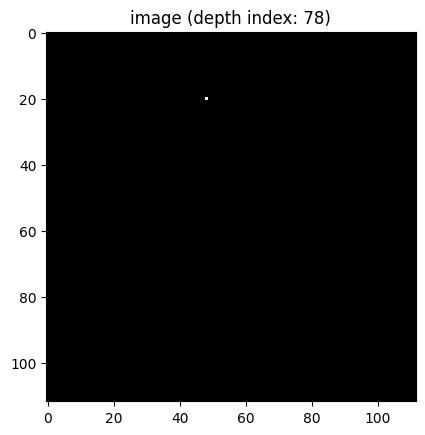

: 

In [ ]:
import matplotlib.pyplot as plt

def visualize_2D_samples(img, depth_index):
        img = img[:,:,depth_index]
        plt.imshow(img, cmap='gray', interpolation = 'nearest')
        plt.title(f"image (depth index: {depth_index})")

        plt.show()

visualize_2D_samples(pred_img, 78)

In [2]:
import os
len([f for f in os.listdir('/nas_homes/yoonji/medmask/Totalsegmentator_dataset_v1/Totalsegmentator_dataset/s0864/segmentations')])

104

In [4]:
import nibabel as nib
img_dir = "/nas_homes/yoonji/medmask/nnUNet_raw/Dataset606_all_TotalSegmentator_previous/imagesTs/TotalSegmentator_0470_0000.nii.gz"
label_dir = "/nas_homes/yoonji/medmask/nnUNet_raw/Dataset606_all_TotalSegmentator_previous/labelsTs/TotalSegmentator_0470.nii.gz"
img = nib.load(img_dir).get_fdata()
label = nib.load(label_dir).get_fdata()

print(img.shape)
print(label.shape)



(233, 233, 228)
(233, 233, 228)
